In [45]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings("ignore")
 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

import spacy
nlp = spacy.load("en_core_web_sm")
 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
 
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.lda_model

In [61]:
%load_ext autoreload
%autoreload 2

In [46]:
import sys
sys.path.append("..")

In [47]:
from bertopic import BERTopic

# 0. LOAD DATA

In [48]:
df = pd.read_csv("../data/review_text_analytics.csv")   # ← swap with your file path
df = df[df["REVIEW_TEXT"].notna()].copy()
df = df[df["REVIEW_TEXT"].str.strip().str.len() > 20].copy()
df = df.reset_index(drop=True)
 
print(f"Loaded {len(df)} reviews")
df[["REVIEW_TEXT", "AVERAGE_RATING", "RATING_BAND", "SEAT_TYPE"]]

Loaded 1394 reviews


,REVIEW_TEXT,AVERAGE_RATING,RATING_BAND,SEAT_TYPE
0,The first flight of my year went well with Del...,4.33,good,Premium Economy
1,I’m at Maui airport right now and my flight fr...,2.14,medium,Economy Class
2,"I booked a flight, rental car and hotel with D...",2.00,medium,Economy Class
3,I’m at Maui airport right now and my flight fr...,2.14,medium,Economy Class
4,I purchased an international itinerary directl...,1.00,bad,Economy Class
...,...,...,...,...
1389,My husband and I took a trip to celebrate our ...,5.00,good,Economy Class
1390,Los Angeles to New York JFK. Delta One is dece...,3.57,medium,Business Class
1391,"New York to Milan. The flight was good, pushba...",2.33,medium,Economy Class
1392,This was a family holiday to Disney. Myself an...,2.00,medium,Economy Class


In [49]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/ninhgiangnguyen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# 1. PREPROCESSING TEXT

In [50]:
from src.text_util import preprocess, add_bigrams

print("Preprocessing text...")
df["CLEAN_TEXT"] = df["REVIEW_TEXT"].apply(preprocess)
df["CLEAN_TEXT"] = add_bigrams(df["CLEAN_TEXT"].tolist())
print("Done.")

Preprocessing text...
Done.


# 2. TOPIC MODELING — LDA

In [51]:
N_TOPICS = 8       # ← tune this (try 6, 8, 10, 12)
N_WORDS  = 12      # top words to display per topic
 
# Vectorise
vectorizer = CountVectorizer(
    max_df=0.90,       # ignore terms in >90% of docs (too common)
    min_df=5,          # ignore terms in <5 docs (too rare)
    max_features=3000,
    ngram_range=(1, 2)
)
dtm = vectorizer.fit_transform(df["CLEAN_TEXT"])
vocab = vectorizer.get_feature_names_out()

In [52]:
print(f"Training LDA with {N_TOPICS} topics...")
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method="online",
    random_state=42,
    n_jobs=-1
)
lda.fit(dtm)

Training LDA with 8 topics...


,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",8
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'online'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",20
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [53]:
TOPIC_LABELS = {
    0: "Luggage & Baggage",
    1: "Cabin Comfort & Seating",
    2: "Customer Service & Staff",
    3: "Flight Delays & Scheduling",
    4: "Food & Beverages",
    5: "WiFi & Entertainment",
    6: "Check-in & Boarding",
    7: "Value for Money",
}

In [54]:
# Print top words per topic
print("\n── Top words per topic ──")
for idx, topic in enumerate(lda.components_):
    top_words = [vocab[i] for i in topic.argsort()[-N_WORDS:][::-1]]
    label = TOPIC_LABELS.get(idx, f"Topic {idx}")
    print(f"Topic {idx} [{label}]: {', '.join(top_words)}")
 
# Assign dominant topic to each review
topic_dist = lda.transform(dtm)
df["DOMINANT_TOPIC"]       = topic_dist.argmax(axis=1)
df["TOPIC_LABEL"]          = df["DOMINANT_TOPIC"].map(TOPIC_LABELS)
df["TOPIC_CONFIDENCE"]     = topic_dist.max(axis=1)
 
print("\nTopic distribution:")
print(df["TOPIC_LABEL"].value_counts())


── Top words per topic ──
Topic 0 [Luggage & Baggage]: bag, check, luggage, customer, agent, atlanta, service, call, next, help, checked, gate
Topic 1 [Cabin Comfort & Seating]: box, broken, replace, wear, tear, claimed, temperature, pathetic, inside, normal, due, dinner
Topic 2 [Customer Service & Staff]: seat, attendant, gate, never, even, people, minute, rude, made, last, take, like
Topic 3 [Flight Delays & Scheduling]: service, customer, crew, staff, good, experience, attendant, customer service, great, seat, like, even
Topic 4 [Food & Beverages]: complaint, child, daughter, customer, request, policy, month, atlanta, thousand, expense, refund, situation
Topic 5 [WiFi & Entertainment]: hour, delayed, another, delay, hotel, due, gate, atlanta, connecting, next, customer, minute
Topic 6 [Check-in & Boarding]: seat, class, first, first class, economy, business, row, lounge, business class, paid, ticket, premium
Topic 7 [Value for Money]: carryon, check carryon, play, let check, provid

# 3. SENTIMENT ANALYSIS — VADER

In [64]:
from src.sentiment_analytics import get_sentiment

In [56]:
print("Running VADER sentiment...")
df[["SENTIMENT_SCORE","SENTIMENT_LABEL",
    "SENTIMENT_POS","SENTIMENT_NEG","SENTIMENT_NEU"]] = \
    df["REVIEW_TEXT"].apply(get_sentiment)
 
print(df["SENTIMENT_LABEL"].value_counts())
 
# Validate — VADER sentiment vs AVERAGE_RATING correlation
corr = df[["SENTIMENT_SCORE","AVERAGE_RATING"]].corr().iloc[0,1]
print(f"\nVADER vs Average Rating correlation: {corr:.3f}")
 

Running VADER sentiment...
SENTIMENT_LABEL
Negative    842
Positive    534
Neutral      18
Name: count, dtype: int64

VADER vs Average Rating correlation: 0.601


# 4. ASPECT-BASED SENTIMENT ANALYSIS (ABSA)

In [66]:
from src.aspect_based_analytics import extract_absa, ASPECTS

In [67]:
print("Running ABSA (this may take a minute)...")
absa_results = df["REVIEW_TEXT"].apply(extract_absa)
 
# Flatten ABSA into per-aspect columns
for aspect in ASPECTS:
    df[f"ABSA_{aspect.replace(' ','_')}_score"] = absa_results.apply(
        lambda x: x.get(aspect, {}).get("sentiment", np.nan)
    )
    df[f"ABSA_{aspect.replace(' ','_')}_words"] = absa_results.apply(
        lambda x: x.get(aspect, {}).get("opinion_words", "")
    )

Running ABSA (this may take a minute)...


In [68]:
print("\n── Aspect Sentiment Summary ──")
absa_summary = {}
for aspect in ASPECTS:
    col = f"ABSA_{aspect.replace(' ','_')}_score"
    mean_score = df[col].dropna().mean()
    count       = df[col].notna().sum()
    absa_summary[aspect] = {"mean_sentiment": round(mean_score, 3),
                             "mention_count":  count}
    print(f"{aspect:20s}: {mean_score:+.3f}  (n={count})")
 
absa_df = pd.DataFrame(absa_summary).T.reset_index()
absa_df.columns = ["aspect", "mean_sentiment", "mention_count"]
absa_df = absa_df.sort_values("mean_sentiment")


── Aspect Sentiment Summary ──
Seat Comfort        : +0.010  (n=289)
Cabin Staff         : +0.038  (n=372)
Food                : +0.041  (n=131)
WiFi                : -0.048  (n=89)
Entertainment       : +0.042  (n=62)
Ground Service      : -0.027  (n=232)
Delays              : -0.049  (n=652)
Value               : +0.020  (n=118)


# 5. VISUALISATIONS

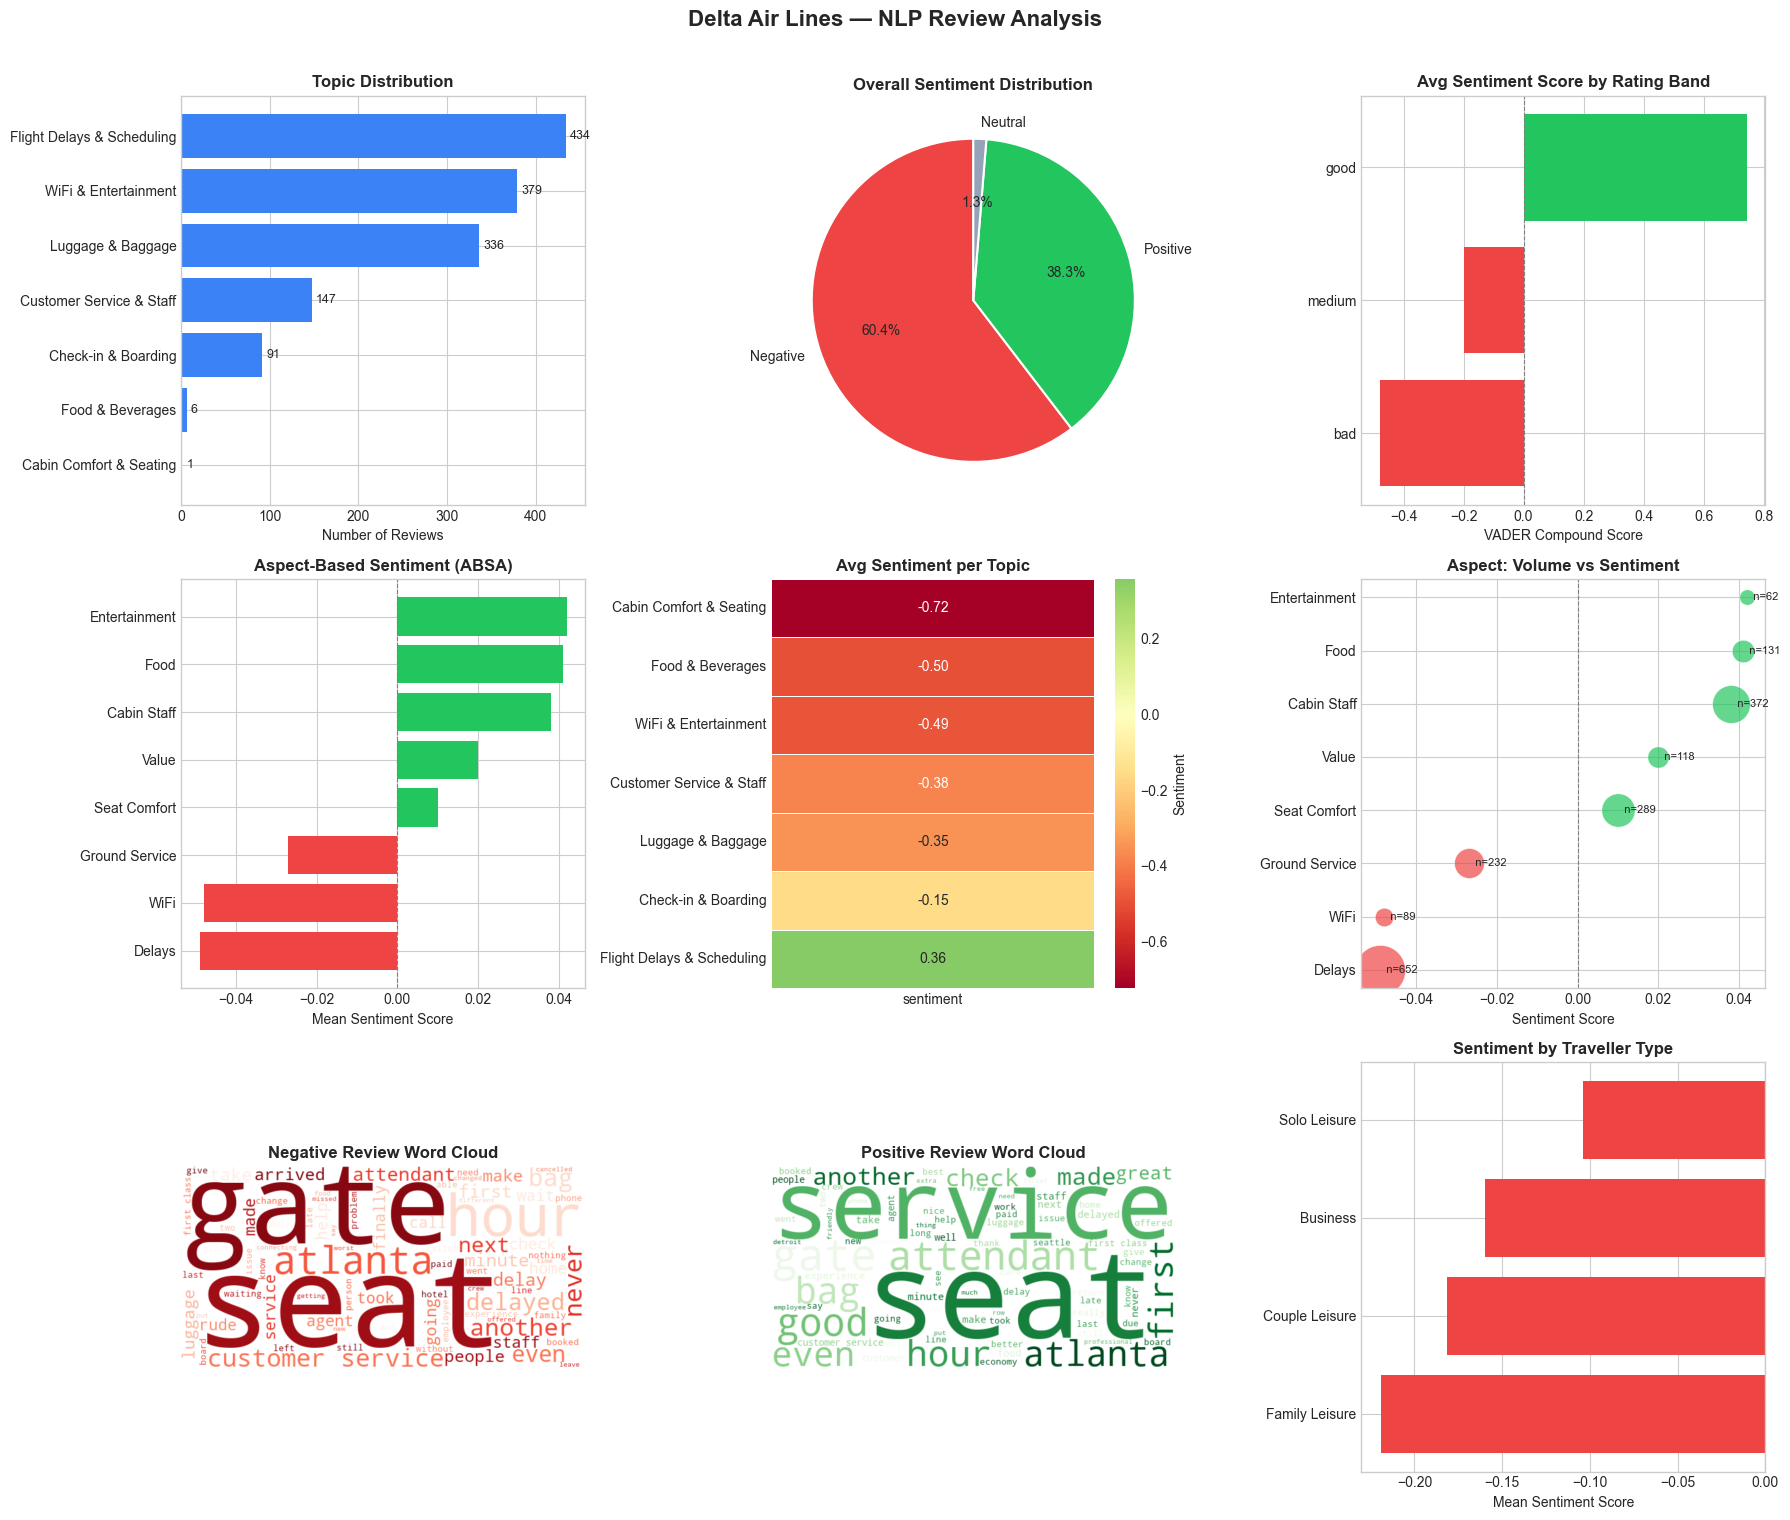

Saved → delta_nlp_analysis.png


In [70]:
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"Positive":"#22c55e", "Negative":"#ef4444", "Neutral":"#94a3b8"}
 
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Delta Air Lines — NLP Review Analysis",
             fontsize=16, fontweight="bold", y=1.01)
 
 
# ── Plot 1: Topic Distribution ────────────────────────────────
ax = axes[0, 0]
topic_counts = df["TOPIC_LABEL"].value_counts()
bars = ax.barh(topic_counts.index, topic_counts.values, color="#3b82f6")
ax.set_title("Topic Distribution", fontweight="bold")
ax.set_xlabel("Number of Reviews")
for bar, val in zip(bars, topic_counts.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
ax.invert_yaxis()
 
 
# ── Plot 2: Sentiment Distribution ───────────────────────────
ax = axes[0, 1]
sent_counts = df["SENTIMENT_LABEL"].value_counts()
ax.pie(sent_counts.values,
       labels=sent_counts.index,
       colors=[COLORS[l] for l in sent_counts.index],
       autopct="%1.1f%%", startangle=90,
       wedgeprops={"edgecolor":"white", "linewidth":1.5})
ax.set_title("Overall Sentiment Distribution", fontweight="bold")
 
 
# ── Plot 3: Sentiment by Rating Band ─────────────────────────
ax = axes[0, 2]
sent_rating = df.groupby("RATING_BAND")["SENTIMENT_SCORE"].mean().sort_values()
colors = ["#ef4444" if v < 0 else "#22c55e" for v in sent_rating.values]
ax.barh(sent_rating.index, sent_rating.values, color=colors)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Avg Sentiment Score by Rating Band", fontweight="bold")
ax.set_xlabel("VADER Compound Score")
 
 
# ── Plot 4: ABSA — Aspect Sentiment ──────────────────────────
ax = axes[1, 0]
colors = ["#ef4444" if v < 0 else "#22c55e"
          for v in absa_df["mean_sentiment"]]
ax.barh(absa_df["aspect"], absa_df["mean_sentiment"], color=colors)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Aspect-Based Sentiment (ABSA)", fontweight="bold")
ax.set_xlabel("Mean Sentiment Score")
 
 
# ── Plot 5: Topic × Sentiment Heatmap ────────────────────────
ax = axes[1, 1]
topic_sent = df.groupby("TOPIC_LABEL")["SENTIMENT_SCORE"].mean().sort_values()
topic_sent_df = pd.DataFrame({"topic": topic_sent.index,
                               "sentiment": topic_sent.values})
pivot = topic_sent_df.set_index("topic")
sns.heatmap(pivot, ax=ax, cmap="RdYlGn", center=0,
            annot=True, fmt=".2f", cbar_kws={"label":"Sentiment"},
            linewidths=0.5)
ax.set_title("Avg Sentiment per Topic", fontweight="bold")
ax.set_ylabel("")
 
 
# ── Plot 6: Topic Volume vs Sentiment (Bubble) ────────────────
ax = axes[1, 2]
for _, row in absa_df.iterrows():
    color = "#ef4444" if row["mean_sentiment"] < 0 else "#22c55e"
    ax.scatter(row["mean_sentiment"], row["aspect"],
               s=row["mention_count"] * 2,
               color=color, alpha=0.7, edgecolors="white", linewidth=0.5)
    ax.text(row["mean_sentiment"], row["aspect"],
            f"  n={int(row['mention_count'])}", va="center", fontsize=8)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Aspect: Volume vs Sentiment", fontweight="bold")
ax.set_xlabel("Sentiment Score")
 
 
# ── Plot 7: WordCloud — Negative Reviews ─────────────────────
ax = axes[2, 0]
neg_text = " ".join(
    df[df["SENTIMENT_LABEL"] == "Negative"]["CLEAN_TEXT"].tolist()
)
wc = WordCloud(width=600, height=300, background_color="white",
               colormap="Reds", max_words=80).generate(neg_text)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Negative Review Word Cloud", fontweight="bold")
 
 
# ── Plot 8: WordCloud — Positive Reviews ─────────────────────
ax = axes[2, 1]
pos_text = " ".join(
    df[df["SENTIMENT_LABEL"] == "Positive"]["CLEAN_TEXT"].tolist()
)
wc = WordCloud(width=600, height=300, background_color="white",
               colormap="Greens", max_words=80).generate(pos_text)
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Positive Review Word Cloud", fontweight="bold")
 
 
# ── Plot 9: Sentiment by Traveller Type ──────────────────────
ax = axes[2, 2]
trav_sent = (df.groupby("TYPE_OF_TRAVELLER")["SENTIMENT_SCORE"]
               .mean().sort_values())
colors = ["#ef4444" if v < 0 else "#22c55e" for v in trav_sent.values]
ax.barh(trav_sent.index, trav_sent.values, color=colors)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Sentiment by Traveller Type", fontweight="bold")
ax.set_xlabel("Mean Sentiment Score")
 
 
plt.tight_layout()
plt.savefig("delta_nlp_analysis.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → delta_nlp_analysis.png")

# 6. LDA INTERACTIVE VISUALISATION

In [71]:
print("Generating interactive LDA viz...")
panel = pyLDAvis.lda_model.prepare(lda, dtm, vectorizer)
pyLDAvis.save_html(panel, "lda_topics.html")
print("Saved → lda_topics.html  (open in browser)")

Generating interactive LDA viz...
Saved → lda_topics.html  (open in browser)


# 7. EXPORT ENRICHED DATASET

In [72]:
export_cols = [
    "REVIEW_KEY", "REVIEW_TEXT", "AVERAGE_RATING", "RATING_BAND",
    "SEAT_TYPE", "TYPE_OF_TRAVELLER", "NATIONALITY",
    "DOMINANT_TOPIC", "TOPIC_LABEL", "TOPIC_CONFIDENCE",
    "SENTIMENT_SCORE", "SENTIMENT_LABEL",
] + [c for c in df.columns if c.startswith("ABSA_") and "_score" in c]
 
df[export_cols].to_csv("delta_reviews_enriched.csv", index=False)
print("Saved → delta_reviews_enriched.csv")

Saved → delta_reviews_enriched.csv


# 8. SUMMARY TABLE FOR STAKEHOLDER

In [73]:
print("\n══ STAKEHOLDER SUMMARY ══")
 
print("\n1. Top Topics by Volume:")
print(df["TOPIC_LABEL"].value_counts().to_string())
 
print("\n2. Sentiment per Topic:")
print(df.groupby("TOPIC_LABEL")["SENTIMENT_SCORE"]
        .agg(["mean","count"])
        .round(3)
        .sort_values("mean")
        .to_string())
 
print("\n3. Most Negative Aspects (ABSA):")
print(absa_df.sort_values("mean_sentiment")
             .head(3)[["aspect","mean_sentiment","mention_count"]]
             .to_string(index=False))
 
print("\n4. Sentiment by Seat Type:")
print(df.groupby("SEAT_TYPE")["SENTIMENT_SCORE"]
        .mean().round(3).sort_values().to_string())
 
print("\n5. Sentiment by Traveller Type:")
print(df.groupby("TYPE_OF_TRAVELLER")["SENTIMENT_SCORE"]
        .mean().round(3).sort_values().to_string())


══ STAKEHOLDER SUMMARY ══

1. Top Topics by Volume:
TOPIC_LABEL
Flight Delays & Scheduling    434
WiFi & Entertainment          379
Luggage & Baggage             336
Customer Service & Staff      147
Check-in & Boarding            91
Food & Beverages                6
Cabin Comfort & Seating         1

2. Sentiment per Topic:
                             mean  count
TOPIC_LABEL                             
Cabin Comfort & Seating    -0.724      1
Food & Beverages           -0.503      6
WiFi & Entertainment       -0.488    379
Customer Service & Staff   -0.379    147
Luggage & Baggage          -0.347    336
Check-in & Boarding        -0.154     91
Flight Delays & Scheduling  0.358    434

3. Most Negative Aspects (ABSA):
        aspect  mean_sentiment  mention_count
        Delays          -0.049          652.0
          WiFi          -0.048           89.0
Ground Service          -0.027          232.0

4. Sentiment by Seat Type:
SEAT_TYPE
Economy Class     -0.210
First Class       -0.0